# Quantum Harmonic Oscillator

Here we compute the ground-state of the $ndim$-dimensional quantum harmonic oscillator for a system of $npart$ particles. The Hamiltonian of the system reads:

$$ H = -\frac{1}{2m} \sum_{i=1}^{npart} \vec{\nabla}_i^2 + \frac{m \omega^2}{2}\sum_{i=1}^{npart} \vec{x}_i^2 $$

For simplicity, we take $m=1$ and $\omega=1$. According to the variational principle of quantum mechanics, for any bosonic variational wave function $|\psi_V\rangle$,

$$ \frac{\langle \psi_V | H | \psi_V \rangle}{\langle \psi_V | \psi_V \rangle} ~ \ge ~ E_0 = \frac{1}{2} ndim * npart $$

In this notebook, we solve both a system of bosons and a system of fermions. The boson ansatz reads:

$$ \langle R | \psi_V \rangle = \psi_V(R) = \exp \left[\sum_i \mathcal{U}(\vec{r}_i)\right]$$

Note that the ground state corresponds to

$$ \psi_0(R) = \exp \left(-\frac{1}{2}\sum_i \vec{r}_i^2\right) $$


## Mathematical and Computational Framework

### 1. Variational Monte Carlo (VMC)

The variational principle states that for any normalised trial state $|\Psi_V\rangle$,

$$
E_V \;=\; \frac{\langle\Psi_V|H|\Psi_V\rangle}{\langle\Psi_V|\Psi_V\rangle}
\;\ge\; E_0.
$$

In position representation with $R = (\mathbf{r}_1,\dots,\mathbf{r}_{N_p})\in\mathbb{R}^{N_p\cdot d}$
this becomes

$$
E_V = \int |\Psi_V(R)|^2\, E_L(R)\, dR \;\bigg/\; \int |\Psi_V(R)|^2\, dR
\;=\; \langle E_L \rangle_{|\Psi_V|^2},
$$

where the **local energy** is

$$
E_L(R) = \frac{H\Psi_V(R)}{\Psi_V(R)}.
$$

The expectation value is estimated by Markov-Chain Monte Carlo sampling from
$\pi(R) = |\Psi_V(R)|^2$, giving the **VMC estimator**

$$
\hat{E} = \frac{1}{N_s}\sum_{k=1}^{N_s} E_L(R_k), \qquad R_k \sim |\Psi_V|^2.
$$

### 2. Neural-Network Wave Functions

Both the bosonic and fermionic wave functions are parameterised by two
feed-forward neural networks with identical architecture (see class definitions
below), one for the log-amplitude and one for the log-phase:

$$
\ln|\Psi_V(R;\boldsymbol{\theta})| = f_{\mathrm{amp}}(R;\boldsymbol{\theta}_a),
\qquad
\arg\Psi_V(R;\boldsymbol{\theta}) = \pi\, f_{\mathrm{ph}}(R;\boldsymbol{\theta}_p),
$$

so that

$$
\ln\Psi_V = f_{\mathrm{amp}} + i\pi f_{\mathrm{ph}}.
$$

Each network has architecture

$$
\mathbb{R}^d \xrightarrow{\mathrm{Dense}(16)} \xrightarrow{\tanh}
\mathbb{R}^{16} \xrightarrow{\mathrm{Dense}(16)} \xrightarrow{\tanh}
\mathbb{R}^{16} \xrightarrow{\mathrm{Dense}(n_\mathrm{out})} \mathbb{R}^{n_\mathrm{out}},
$$

where $n_\mathrm{out}=1$ for bosons and $n_\mathrm{out}=N_p$ for fermions.
For a single particle position $\mathbf{r}\in\mathbb{R}^d$, each dense layer computes

$$
\mathbf{z}^{(l)} = \tanh\!\left(W^{(l)}\mathbf{z}^{(l-1)} + \mathbf{b}^{(l)}\right),
$$

with weights $W^{(l)}$ and biases $\mathbf{b}^{(l)}$ initialised by the Glorot
(Xavier) scheme: $W_{ij}\sim\mathcal{U}[-c/\sqrt{n_{\mathrm{in}}+n_{\mathrm{out}}},\,
c/\sqrt{n_{\mathrm{in}}+n_{\mathrm{out}}}]$.
An additional Gaussian envelope term $-0.04\sum_i|\mathbf{r}_i|^2$ is subtracted
from the log-wave-function to impose the physical boundary condition
$\Psi_V\to 0$ as $|\mathbf{r}|\to\infty$.

### 3. Bosonic Wave Function

For $N_p$ identical bosons the wave function is symmetric under particle exchange.
The network is applied to each particle coordinate independently and the
log-amplitudes are **summed** over particles:

$$
\ln\Psi_V^{\mathrm{bos}}(R) = \sum_{i=1}^{N_p}\left[
f_{\mathrm{amp}}(\mathbf{r}_i;\boldsymbol{\theta}_a)
+ i\pi f_{\mathrm{ph}}(\mathbf{r}_i;\boldsymbol{\theta}_p)
\right] - 0.04\sum_i|\mathbf{r}_i|^2.
$$

Summing log-amplitudes is equivalent to taking the product of single-particle
wave functions, which automatically satisfies Bose symmetry.

### 4. Fermionic Wave Function — Slater Determinant

For $N_p$ spin-polarised fermions the wave function must be **antisymmetric**.
The network outputs an $N_p\times N_p$ matrix $\Phi_{ij}$ (the $i$-th row
corresponds to the $i$-th particle, the $j$-th column to the $j$-th
single-particle orbital):

$$
\Phi_{ij}(R) = \exp\!\left[f_{\mathrm{amp}}(\mathbf{r}_i;\boldsymbol{\theta}_a)_j
+ i\pi f_{\mathrm{ph}}(\mathbf{r}_i;\boldsymbol{\theta}_p)_j\right].
$$

The wave function is then the **Slater determinant**

$$
\Psi_V^{\mathrm{fer}}(R) = \det\Phi(R),
$$

computed in log-space via `jnp.linalg.slogdet` for numerical stability:

$$
\ln\Psi_V^{\mathrm{fer}} = \ln|\det\Phi| + i\,\arg(\mathrm{sign}(\det\Phi))
- 0.04\sum_i|\mathbf{r}_i|^2.
$$

### 5. Local Energy and Kinetic Term

The Hamiltonian is $H = -\tfrac{1}{2}\nabla^2 + V(R)$ with $V=\tfrac{1}{2}\sum_i|\mathbf{r}_i|^2$.
In the log-wave-function representation the kinetic local energy is

$$
E_K(R) = -\frac{1}{2}\frac{\nabla^2\Psi_V}{\Psi_V}
= -\frac{1}{2}\left[\sum_{\alpha}\frac{\partial^2 \ln\Psi_V}{\partial r_\alpha^2}
+ \sum_{\alpha}\left(\frac{\partial \ln\Psi_V}{\partial r_\alpha}\right)^2\right],
$$

where the index $\alpha$ runs over all $N_p\cdot d$ coordinates.
Both the first and second derivatives are obtained by **automatic differentiation**
via `jax.grad` and `jax.hessian`.  For a complex $\ln\Psi_V$,
real and imaginary parts are differentiated separately and recombined.

### 6. Energy Gradient and Optimisation

The gradient of the variational energy with respect to parameters $\boldsymbol{\theta}$ is

$$
\nabla_{\boldsymbol{\theta}}E_V = 2\,\mathrm{Re}\!
\left[\langle E_L\, \mathcal{O}^* \rangle - \langle E_L\rangle\langle\mathcal{O}^*\rangle\right],
$$

where $\mathcal{O}_k = \partial_k\ln\Psi_V$ is the **log-derivative** (also called
the score function).  The code evaluates this by computing

$$
\mathbf{f} = \frac{2}{N_s}\mathrm{Re}\!\left[\tilde{\mathbf{E}}\cdot\tilde{\mathcal{O}}^*\right],
\quad \tilde{E}_k = E_L(R_k)-\hat{E},\quad
\tilde{\mathcal{O}}_{k,i} = \mathcal{O}_{k,i}-\bar{\mathcal{O}}_i,
$$

which is an unbiased Monte Carlo estimate of the gradient.

Three optimisers are available:

| Optimiser | Update rule |
|:----------|:------------|
| **SGD** | $\boldsymbol{\theta}\leftarrow\boldsymbol{\theta}-\eta\mathbf{f}$ |
| **Adam** | $\boldsymbol{\theta}\leftarrow\boldsymbol{\theta}-\eta\,\hat{m}/(\sqrt{\hat{v}}+\epsilon)$ |
| **SR** (Stochastic Reconfiguration) | $\boldsymbol{\theta}\leftarrow\boldsymbol{\theta}-\eta\,S^{-1}\mathbf{f}$ |

The **Stochastic Reconfiguration** (SR) preconditioner uses the quantum geometric
tensor (quantum Fisher matrix)

$$
S_{ij} = \langle\mathcal{O}_i^*\mathcal{O}_j\rangle - \langle\mathcal{O}_i^*\rangle\langle\mathcal{O}_j\rangle,
$$

regularised as $S\to S + \varepsilon\,\mathrm{diag}(1+\sqrt{\hat{g}^2})$
(where $\hat{g}^2$ is the RMSProp-style running second moment of $\mathbf{f}$),
and solved via a Cholesky decomposition.

### 7. Metropolis–Hastings Sampling

Configurations $R$ are sampled from $|\Psi_V(R)|^2$ using the
**Metropolis–Hastings algorithm** with a Gaussian proposal:

$$
R' = R + \sigma\,\boldsymbol{\xi},\qquad \boldsymbol{\xi}\sim\mathcal{N}(0,I).
$$

The move is accepted with probability

$$
A(R\to R') = \min\!\left(1,\,\frac{|\Psi_V(R')|^2}{|\Psi_V(R)|^2}\right).
$$

After `neq` equilibration sweeps, `nav` measurement sweeps of `nvoid`
Metropolis steps each are performed, giving `nav * nwalk` statistically
independent configurations (up to the autocorrelation of the chain).


In [1]:
# Load the libraries that we need for this notebook
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, clear_output

import jax
import jaxlib
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax import random, grad, jit, vmap, pmap, jacfwd, jacrev
from jax.example_libraries import stax
from jax.lax import fori_loop
from functools import partial

from jax.example_libraries.stax import (BatchNorm, Conv, Dense, Flatten,
                                   Relu, Gelu, LogSoftmax, Softplus, Tanh,
                                   Sigmoid, elementwise, FanOut, FanInConcat)
from jax.nn.initializers import glorot_normal, normal, ones, zeros

from jax.tree_util import tree_flatten
from jax.flatten_util import ravel_pytree
from jax.scipy.linalg import cho_factor, cho_solve

In [2]:
class WavefunctionBoson(object):
    """Create a wave function in ndim dimensions and for npart
    bosons using a dense complex feed-forward neural net as
    a building block
    """
    def __init__(self, ndim : int, npart : int):
        self.ndim = ndim
        self.npart = npart
        self.activation = Tanh
        self.ndense = 16

    def build(self, key):
        in_shape = (-1, self.ndim)

        self.dense_init, self.dense_apply = stax.serial(
        Dense(self.ndense), self.activation,
        Dense(self.ndense), self.activation,
        Dense(1),
)
        key, key_input = jax.random.split(key)
        _, amplitude_params = self.dense_init(key_input, in_shape)

        key, key_input = jax.random.split(key)
        _, phase_params = self.dense_init(key_input, in_shape)

        net_params = [amplitude_params] + [phase_params]

        net_params = jax.tree_util.tree_map(self.update_cast, net_params)
        flat_net_params = self.flatten_params(net_params)
        num_flat_params = flat_net_params.shape[0]

        return net_params, num_flat_params

    @partial(jit, static_argnums=(0,))
    def logpsi(self, params, r):

        amplitude_params, phase_params = params
        amplitude = self.dense_apply(amplitude_params, r)
        phase = self.dense_apply(phase_params, r)

        logpsi = amplitude + 1j * jnp.pi * phase
        logpsi = jnp.sum(logpsi, axis = 0) # Here I am summing over the particles; only valid for bosons
        logpsi = jnp.reshape(logpsi, ())
        logpsi = logpsi - 0.04 * jnp.sum(r**2)
        return logpsi

    @partial(jit, static_argnums=(0,))
    def vmap_logpsi(self, params, r):
        vmap_logpsi = vmap(self.logpsi, in_axes=(None, 0))(params, r)
        return vmap_logpsi

    @partial(jit, static_argnums=(0,))
    def flatten_params(self, parameters):
        flatten_parameters, self.unravel = ravel_pytree(parameters)
        return flatten_parameters

    @partial(jit, static_argnums=(0,))
    def unflatten_params(self, flatten_parameters):
        unflatten_parameters = self.unravel(flatten_parameters)
        return unflatten_parameters

    @partial(jit, static_argnums=(0,))
    def update_add(self, params, dparams):
        return params + dparams

    @partial(jit, static_argnums=(0,))
    def update_cast(self, params):
        return params.astype(jnp.float64)

In [3]:
class WavefunctionFermion(object):
    """Create a wave function in ndim dimensions and for npart
    fermions using a dense complex feed-forward neural net as
    a building block
    """
    def __init__(self, ndim : int, npart : int):
        self.ndim = ndim
        self.npart = npart
        self.activation = Tanh
        self.ndense = 16

    def build(self, key):
        in_shape = (-1, self.ndim)

        self.dense_init, self.dense_apply = stax.serial(
        Dense(self.ndense), self.activation,
        Dense(self.ndense), self.activation,
        Dense(self.npart),
)
        key, key_input = jax.random.split(key)
        _, amplitude_params = self.dense_init(key_input, in_shape)

        key, key_input = jax.random.split(key)
        _, phase_params = self.dense_init(key_input, in_shape)

        net_params = [amplitude_params] + [phase_params]

        net_params = jax.tree_util.tree_map(self.update_cast, net_params)
        flat_net_params = self.flatten_params(net_params)
        num_flat_params = flat_net_params.shape[0]

        return net_params, num_flat_params

    @partial(jit, static_argnums=(0,))
    def logpsi(self, params, r):

        amplitude_params, phase_params = params
        amplitude = self.dense_apply(amplitude_params, r)
        phase = self.dense_apply(phase_params, r)

        phi = jnp.exp( amplitude + 1j * jnp.pi * phase )

        phase, logpsi = jnp.linalg.slogdet(phi)
        phase = jnp.imag(jnp.log(phase))

        logpsi = logpsi - 0.04 * jnp.sum(r**2)

        return logpsi + 1j * phase

    @partial(jit, static_argnums=(0,))
    def vmap_logpsi(self, params, r):
        vmap_logpsi = vmap(self.logpsi, in_axes=(None, 0))(params, r)
        return vmap_logpsi

    @partial(jit, static_argnums=(0,))
    def flatten_params(self, parameters):
        flatten_parameters, self.unravel = ravel_pytree(parameters)
        return flatten_parameters

    @partial(jit, static_argnums=(0,))
    def unflatten_params(self, flatten_parameters):
        unflatten_parameters = self.unravel(flatten_parameters)
        return unflatten_parameters

    @partial(jit, static_argnums=(0,))
    def update_add(self, params, dparams):
        return params + dparams

    @partial(jit, static_argnums=(0,))
    def update_cast(self, params):
        return params.astype(jnp.float64)

In [4]:
class Hamiltonian(object):
    """Expectation values of the kinetic and potential energies of
       a collection of independent harmonic oscillators.
    """
    def __init__(self, ndim : int, npart : int, wavefunction : callable):
       self.ndim = ndim
       self.npart = npart
       self.wavefunction = wavefunction

    @partial(jit, static_argnums=(0,))
    def potential (self, x):
        """ The HO oscillator potential is given by
        V = <x|V|psi> / <x|psi> = 1/2 sum_i x_i^2
        """
        pe = 0.5 * jnp.sum(x**2, axis=(1,2))
        return pe

    @partial(jit, static_argnums=(0,))
    def kinetic(self, params, r):
        """ Use autodiff to compute the kinetic energy
        """
        logpsi_r = lambda r: jnp.real(self.wavefunction.logpsi(params, r))
        logpsi_i = lambda r: jnp.imag(self.wavefunction.logpsi(params, r))

        d_logpsi_r = jax.grad(logpsi_r)(r)
        d2_logpsi_r = jax.hessian(logpsi_r)(r)
        d2_logpsi_r = jnp.reshape(d2_logpsi_r, (self.ndim * self.npart, self.ndim * self.npart))

        d_logpsi_i = jax.grad(logpsi_i)(r)
        d2_logpsi_i = jax.hessian(logpsi_i)(r)
        d2_logpsi_i = jnp.reshape(d2_logpsi_i, (self.ndim * self.npart, self.ndim * self.npart))

        d_logpsi = d_logpsi_r + 1j * d_logpsi_i
        d2_logpsi = d2_logpsi_r + 1j * d2_logpsi_i
        ke = - 0.5 * ( jnp.trace(d2_logpsi) + jnp.sum( d_logpsi * d_logpsi ) )
        return ke


    @partial(jit, static_argnums=(0,))
    def energy (self, params, r):
        """ Sum of the kinetic and the potential energy """
        ke = vmap(self.kinetic, in_axes=(None, 0))(params, r)
        pe = self.potential(r)
        en = ke + pe
        return ke, pe, en

In [5]:
class Metropolis(object):
    """Metropolis Sampler in N dimension

    Sample from N-D coordinates, using some initial probability distribution

    """
    def __init__(self,
          nwalk : int,
          npart : int,
          ndim : int,
          neq : int,
          nav : int,
          nvoid : int,
          sig : float,
          sig_i : float,
          wavefunction : callable):

          self.nwalk = nwalk
          self.npart = npart
          self.ndim = ndim
          self.neq = neq
          self.nav = nav
          self.nvoid = nvoid
          self.sig = sig
          self.sig_i = sig_i
          self.wavefunction = wavefunction

    # Function that performs nvoid Metropolis steps
    @partial(jit, static_argnums=(0,))
    def step(self, params, x_o, key_o):

        def single_step(i, loop_carry):
            x_o, key_o, acc_o = loop_carry
            log_wpsi_o = self.wavefunction.vmap_logpsi(params, x_o)
            key_o, key_input = jax.random.split(key_o)
            x_n = x_o + self.sig * jax.random.normal(key_input, shape=[self.nwalk, self.npart, self.ndim])
            log_wpsi_n = self.wavefunction.vmap_logpsi(params, x_n)
            prob = jnp.abs(jnp.exp( 2 * ( log_wpsi_n - log_wpsi_o ) ))
            key_o, key_input = jax.random.split(key_o)
            accept = jnp.greater(prob, jax.random.uniform(key_input, shape=[self.nwalk]))
            x_o = jnp.where(accept.reshape([self.nwalk, 1, 1]), x_n, x_o)
            acc_o = accept.astype('float64')
            return x_o, key_o, acc_o

        acc_o = jnp.zeros(self.nwalk)
        x_o, key_o, acc_o = fori_loop(0, self.nvoid, single_step, (x_o, key_o, acc_o))
        return x_o, acc_o, key_o

    # Function that performs the full Metropolis walk and returns the path and the acceptance
    def walk(self, params, key):
        key_o, key_input = jax.random.split(key)
        x_o = self.sig_i * jax.random.normal(key_input, shape=[self.nwalk, self.npart, self.ndim])
        # BUG FIX: was 'neq' (bare name), should be 'self.neq'
        for i in range(self.neq):
            x_o, acc_o, key_o = self.step(params, x_o, key_o)
        x_s = []
        acc_s = []
        for i in range(self.nav):
            x_o, acc_o, key_o = self.step(params, x_o, key_o)
            x_s.append(x_o)
            acc_s.append(acc_o)
        x_s = jnp.concatenate(x_s)
        acc_s = jnp.concatenate(acc_s)
        return x_s, acc_s


In [6]:
# Define the function that computes the average and the standard error of the mean
# for each observable.
#
# Standard error of the mean: SEM = std(x) / sqrt(N)
#   where std(x)^2 = mean(x^2) - mean(x)^2  (biased estimator, fine for large N)
#
# BUG FIX: original code divided by sqrt(N-1), which overestimates the SEM.
# Correct formula: SEM = sqrt(mean(x^2) - mean(x)^2) / sqrt(N)
@jit
def estimator(observable):
    average   = jnp.mean(observable)
    average_2 = jnp.mean(observable**2)
    error = jnp.sqrt(average_2 - average**2) / jnp.sqrt(observable.shape[0])
    return average, error


In [7]:
class Optimizer(object):
    """Class that computes the energy derivative
    f_i = 2 Re[< E_L O_i* > - < E_L > < O_i* >]
    and updates the parameters according to the SGD algorithm
    """
    def __init__(self, ndim : int, npart : int, nparams : int, wavefunction : callable):
        self.ndim = ndim
        self.npart = npart
        self.nparams = nparams
        self.wavefunction = wavefunction
        self.alpha = 0.9
        self.beta = 0.99
        self.g2_i = jnp.zeros(self.nparams)
        self.m_i = jnp.zeros(self.nparams)

    @partial(jit, static_argnums=(0,))
    def getder(self, params, x):
        logpsi_r = lambda params: jnp.real(self.wavefunction.logpsi(params, x))
        logpsi_i = lambda params: jnp.imag(self.wavefunction.logpsi(params, x))
        dlogpsi_r = self.wavefunction.flatten_params(jax.grad(logpsi_r)(params))
        dlogpsi_i = self.wavefunction.flatten_params(jax.grad(logpsi_i)(params))
        dlogpsi = dlogpsi_r + 1j * dlogpsi_i
        return dlogpsi

    @partial(jit, static_argnums=(0,))
    def vmap_getder(self, params, x):
        return vmap(self.getder, in_axes=(None, 0))(params, x)

# Computes the gradient of the energy f_i = 2[ < E_L O_i > - 2 < E_L > < O_i > ]
    @partial(jit, static_argnums=(0,))
    def gradient (self, params, x, en):
        nsamples = en.shape[0]
        jac = self.vmap_getder(params, x)
        jac = jac - jnp.mean(jac, axis=0)
        jac_conjugate = jnp.conjugate(jac)
        en = en - jnp.mean(en)
        grad_energy = jnp.real(2 * jnp.matmul(en, jac_conjugate) / nsamples)
        return grad_energy, jac

    @partial(jit, static_argnums=(0,))
    def sgd(self, params, grad_energy):
        """Parameters' update according to the SGD algorithm
      Args:
      params: initial variational parameters
      r: array with shape (n_devices, nwalk * nav, npart, ndim)
      sz: array with shape (n_devices, nwalk * nav, npart, 2)
      energy: array with shape (n_devices, nwalk * nav)

      Returns:
      dp_i: array with the same shape as ``params`` representing the best parameters' update (nparams)
      """
        f_i = grad_energy
        dp_i = f_i
        return dp_i

    @partial(jit, static_argnums=(0,))
    def adam(self, itr, params, grad_energy, g2_i, m_i):
        """Parameters' update according to the Adam algorithm
      Args:
      params: initial variational parameters
      r: array with shape (n_devices, nwalk * nav, npart, ndim)
      sz: array with shape (n_devices, nwalk * nav, npart, 2)
      energy: array with shape (n_devices, nwalk * nav)
      m_i: accumulated momentum  (nparams)
      g2_i: accumulated second order derivative squared  (nparams)
      itr : iteration

      Returns:
      dp_i: array with the same shape as ``params`` representing the best parameters' update (nparams)
      g2_i: updated accumulated second order derivative squared (nparams)
      m_i: updated accumulated momentum (nparams)
      """

        f_i = grad_energy
        m_i = self.alpha * m_i + (1. - self.alpha) * f_i
        mh_i = m_i / ( 1. - self.alpha**itr )
        g2_i = self.beta * g2_i + (1. - self.beta) * f_i**2
        g2h_i = g2_i / ( 1. - self.beta**itr )
        dp_i = mh_i / ( jnp.sqrt(g2h_i) + 0.00001 )
        return dp_i, g2_i, m_i

    @partial(jit, static_argnums=(0,))
    def sr_cholesky(self, itr, params, grad_i, jac_ni, nsamples, g2_i):
        """Parameters' update according to the SR algorithm with Cholesky solver
      Args:
      params: initial variational parameters
      r: array with shape (n_devices, nwalk * nav, npart, ndim)
      sz: array with shape (n_devices, nwalk * nav, npart, 2)
      energy: array with shape (n_devices, nwalk, nav)
      g2_i: accumulated second order derivative squared  (nparams)
      itr : iteration

      Returns:
      dp_i: array with the same shape as ``params`` representing the best parameters' update (nparams)
      g2_i: updated accumulated second order derivative squared (nparams)
      """
        eps = 0.01
        g2_i = self.beta * g2_i + (1. - self.beta) * grad_i**2
        g2h_i = g2_i / ( 1. - self.beta**itr )
        S_ij = jnp.matmul(jnp.conjugate(jnp.transpose(jac_ni)), jac_ni) / nsamples + eps * jnp.diag( 1. + jnp.sqrt(g2h_i) )
        S_ij = jnp.real(S_ij)
        U_ij, low = cho_factor(S_ij)
        dp_i = cho_solve((U_ij, low), grad_i)
        return dp_i, g2_i

In [8]:
# Set the parameters and instanciate the Wavefunction, Hamiltonian, and Metropolis classes
sig_i = 1.0         # Gaussian width for sampling the initial configuration
sig = 0.2           # Gaussian width for sampling the Metropolis Move
neq = 10            # Equilibration steps
nav = 10             # Averaging steps
nvoid = 100         # Void steps between energy calculations
nwalk = 400         # Quantum Monte Carlo configurations
ndim = 1            # Spatial dimension
npart = 2           # Number of particles
seed_walk = 19      # Seed to initialize the random-number generator of the Metropolis walk
seed_net = 17       # Seed to initialize the random-number generator of the neural network

key_net = random.PRNGKey(seed_net)
wavefunction = WavefunctionBoson(ndim, npart)
params, nparams = wavefunction.build(key_net)

hamiltonian = Hamiltonian(ndim, npart, wavefunction)
key_walk = random.PRNGKey(seed_walk)
metropolis = Metropolis(nwalk, npart, ndim, neq, nav, nvoid, sig, sig_i, wavefunction)
optimizer = Optimizer(ndim, npart, nparams, wavefunction)

In [9]:
# Define the optimization step and perform the optimization using JAX default optimizer
learning_rate = 0.1

def step_sgd(step, key_input, params):
    x_s, acc_s = metropolis.walk(params, key_input)
    ke, pe, en =  hamiltonian.energy(params, x_s)
    energy_average, energy_error = estimator(en)
    energy_gradient, _  = optimizer.gradient(params, x_s, en)
    dp_i = optimizer.sgd(params, energy_gradient)
    params = wavefunction.flatten_params(params)
    params = params - learning_rate * dp_i
    params = wavefunction.unflatten_params(params)
    return energy_average, energy_error, params

def step_adam(itr, key_input, params):
    itr+=1
    x_s, acc_s = metropolis.walk(params, key_input)
    ke, pe, en =  hamiltonian.energy(params, x_s)
    energy_average, energy_error = estimator(en)
    energy_gradient, _ = optimizer.gradient(params, x_s, en)
    g2_i = optimizer.g2_i
    m_i = optimizer.m_i
    dp_i, optimizer.g2_i, optimizer.m_i = optimizer.adam(itr, params, energy_gradient, g2_i, m_i)
    params = wavefunction.flatten_params(params)
    params = params - learning_rate * dp_i
    params = wavefunction.unflatten_params(params)
    return energy_average, energy_error, params

def step_sr(itr, key_input, params):
    itr += 1
    x_s, acc_s = metropolis.walk(params, key_input)
    ke, pe, en =  hamiltonian.energy(params, x_s)
    energy_average, energy_error = estimator(en)
    nsamples = en.shape[0]
    energy_gradient, jac = optimizer.gradient(params, x_s, en)
    g2_i=optimizer.g2_i
    dp_i, optimizer.g2_i = optimizer.sr_cholesky(itr, params, energy_gradient, jac, nsamples, g2_i)
    params = wavefunction.flatten_params(params)
    params = params-learning_rate * dp_i
    params = wavefunction.unflatten_params(params)
    return energy_average, energy_error, params

In [10]:
steps_history = []
energy_history  = []
error_history = []
params_saved = []
for i in range (21):
    key_walk, key_input = jax.random.split(key_walk)
    #value, error, params = step_sgd(i, key_input, params)
    #value, error, params = step_adam(i, key_input, params)
    value, error, params = step_sr(i, key_input, params)
    print("step", i, "energy = ", value, "err=", error )
    steps_history.append(i)
    energy_history.append(value)
    error_history.append(error)
    params_saved.append(params)

step 0 energy =  (8.397828464834216+0.014286189403567092j) err= (0.10678304044768172-0.001869363848493495j)
step 1 energy =  (5.00891795036171+0.012719397938833334j) err= (0.05865209025786733+0.00040822439978528414j)
step 2 energy =  (3.147505466190604-0.001509251322403037j) err= (0.022955037100340726+0.0025136720367718627j)
step 3 energy =  (2.398575512415241-0.0194531076517145j) err= (0.0029185012452522486+0.010696564893791885j)
step 4 energy =  (1.998057806396122-0.03240983218154689j) err= (0.0015824045673955617+0.01217410873776136j)
step 5 energy =  (1.7083334722243122-0.021372665173875434j) err= (0.001281872530213356+0.011360299173556363j)
step 6 energy =  (1.4906020609829276+0.01139967147034443j) err= (0.0010831789157372805+0.010103280183501968j)
step 7 energy =  (1.3230823195425914-0.008323665754554078j) err= (0.000830717782440866+0.008309325108397629j)
step 8 energy =  (1.2109883377656157-0.008319502911068553j) err= (0.0007144184405139023+0.007065937738763149j)
step 9 energy = 

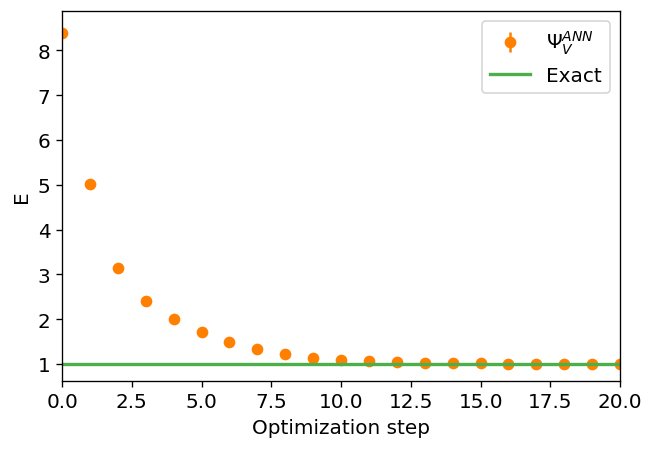

In [11]:
from matplotlib.pyplot import figure
palette = plt.get_cmap('Set1')
figure(num=None, figsize=(6, 4), dpi=120, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 12})

step = jnp.asarray(steps_history)
energy = jnp.real(jnp.asarray(energy_history))
error = jnp.real(jnp.asarray(error_history))

p1 = plt.errorbar(step, energy, yerr=error, fmt='o', errorevery=1, markevery = 1, label = r'$\Psi_{V}^{ANN}$', zorder = 0, color = palette(4))
p2 = plt.axhline(y= 0.5 * npart * ndim, linestyle = '-', label = 'Exact', color = palette(2), lw = 2)

#plt.ylim(0.46,1)
plt.xlim(0,20)

plt.xlabel(r'Optimization step')
plt.ylabel('E')
plt.legend([p1, p2], [r'$\Psi_{V}^{ANN}$', r'Exact'], loc = 'upper right')
plt.savefig("ho_energies.pdf",bbox_inches = 'tight')
plt.show()

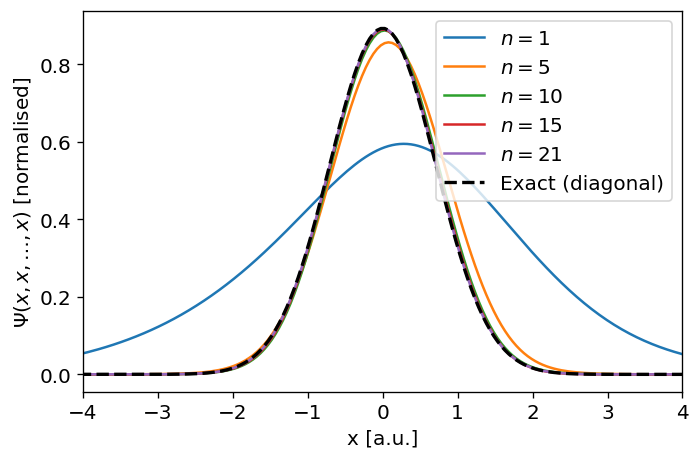

In [12]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

# ─────────────────────────────────────────────────────────────────────────────
# One-dimensional bosonic wave function comparison
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: This plot is only meaningful when the boson run used ndim=1.
#       We evaluate psi(x) by setting ALL npart particle coordinates to x,
#       i.e.  R = (x, x, ..., x),  so r has shape (npart, ndim) = (npart, 1).
#       This gives the diagonal slice of the full multi-particle wave function.
#
# BUG FIX 1: original code passed x of shape (100,) to vmap_logpsi which
#            expects shape (batch, npart, ndim). Fixed by broadcasting x to
#            the correct shape (100, npart, ndim).
#
# BUG FIX 2: original code integrated over [0, 10] only, missing the x < 0
#            half of the (symmetric) wave function. Fixed by using [-5, 5].
# ─────────────────────────────────────────────────────────────────────────────

# Use the boson wavefunction/params from the first run (ndim=1, npart=2)
# Re-instantiate if needed — here we assume the variables are still in scope.

x = jnp.linspace(-5, 5, 200)   # symmetric domain, sufficient to capture Gaussian tails

# Broadcast x to shape (200, npart, ndim) so vmap_logpsi receives correct input
# Each sample has all particles at the same position x (diagonal slice)
x_batch = jnp.tile(x.reshape(-1, 1, 1), (1, npart, ndim))  # shape (200, npart, ndim)

# Exact ground-state wave function for npart independent bosons:
# psi_0(R) = prod_i exp(-x_i^2/2); on the diagonal (all x_i = x):
# psi_0(x,...,x) = exp(-npart * x^2 / 2)
psi_exact_diag = jnp.exp(-0.5 * npart * x**2)
norm_exact = jnp.sqrt(jnp.trapezoid(psi_exact_diag**2, x))
psi_exact_diag = psi_exact_diag / norm_exact

# Evaluate and normalise the ANN wave function at each saved checkpoint
psi_ann = []
for p in params_saved:
    log_psi = jnp.real(wavefunction.vmap_logpsi(p, x_batch))  # shape (200,)
    psi = jnp.exp(log_psi)
    norm = jnp.sqrt(jnp.trapezoid(psi**2, x))
    psi_ann.append(psi / norm)

# ─── Plotting ────────────────────────────────────────────────────────────────
figure(figsize=(6, 4), dpi=120)
plt.rcParams.update({'font.size': 12})
palette = plt.get_cmap('Set1')

snapshots = [0, 4, 9, 14, 20]
labels    = [r'$n=1$', r'$n=5$', r'$n=10$', r'$n=15$', r'$n=21$']

for idx, label in zip(snapshots, labels):
    if idx < len(psi_ann):
        plt.plot(x, psi_ann[idx], '-', label=label)

plt.plot(x, psi_exact_diag, 'k--', lw=2, label='Exact (diagonal)')

plt.xlabel('x [a.u.]')
plt.ylabel(r'$\Psi(x, x, \ldots, x)$ [normalised]')
plt.xlim(-4, 4)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("ho_wavefunction.pdf", bbox_inches='tight')
plt.show()


In [13]:
# Set the parameters and instanciate the Wavefunction, Hamiltonian, and Metropolis classes
sig_i = 1.0         # Gaussian width for sampling the initial configuration
sig = 0.2           # Gaussian width for sampling the Metropolis Move
neq = 10            # Equilibration steps
nav = 10             # Averaging steps
nvoid = 100         # Void steps between energy calculations
nwalk = 400         # Quantum Monte Carlo configurations
ndim = 2            # Spatial dimension
npart = 3           # Number of particles
seed_walk = 19      # Seed to initialize the random-number generator of the Metropolis walk
seed_net = 17       # Seed to initialize the random-number generator of the neural network

key_net = random.PRNGKey(seed_net)
wavefunction = WavefunctionFermion(ndim, npart)
params, nparams = wavefunction.build(key_net)

hamiltonian = Hamiltonian(ndim, npart, wavefunction)
key_walk = random.PRNGKey(seed_walk)
metropolis = Metropolis(nwalk, npart, ndim, neq, nav, nvoid, sig, sig_i, wavefunction)
optimizer = Optimizer(ndim, npart, nparams, wavefunction)

In [14]:
steps_history = []
energy_history  = []
error_history = []
params_saved = []
for i in range (21):
    key_walk, key_input = jax.random.split(key_walk)
    #value, error, params = step_sgd(i, key_input, params)
    #value, error, params = step_adam(i, key_input, params)
    value, error, params = step_sr(i, key_input, params)
    print("step", i, "energy = ", value, "err=", error )
    steps_history.append(i)
    energy_history.append(value)
    error_history.append(error)
    params_saved.append(params)

step 0 energy =  (22.558297541921444+0.006518976256797492j) err= (0.17448266045568875-2.2255184496949236e-05j)
step 1 energy =  (21.985111212620346+0.01519086586611281j) err= (0.1743256348830298-0.00016975059741149373j)
step 2 energy =  (10.897388178785668-0.01124123945425271j) err= (0.08663367811260628+0.000210911181550838j)
step 3 energy =  (6.648847337475897+0.0021925378840825936j) err= (0.027633437764989624+0.0011199007993836403j)
step 4 energy =  (6.1140172677220415+0.013455378155129288j) err= (0.009320832094553214+0.001658021605512119j)
step 5 energy =  (5.845345082105046+0.002523857577004401j) err= (0.006766767204662854+0.0018830701049869858j)
step 6 energy =  (5.673151767763022+0.002557980924131099j) err= (0.006833442143037756+0.0010601442559038537j)
step 7 energy =  (5.528849440854064-0.0014228216975842414j) err= (0.006059118404620115+0.0005702121995875038j)
step 8 energy =  (5.3905190550828594-0.007549805216190295j) err= (0.005836435895481331+0.000303641501705731j)
step 9 ene

In [15]:
import numpy as np
import math

def ground_state_energy_closed_shell(N, d):
    """
    Ground‐state energy for N spin-polarized fermions filling
    *closed* shells in a d-dimensional harmonic oscillator (m=ω=1).

    Parameters
    ----------
    N : int
        Total number of particles. Must satisfy N = C(nF + d, d) for some integer nF ≥ 0.
    d : int
        Number of spatial dimensions (d ≥ 1).

    Returns
    -------
    E0 : float
        Ground‐state energy E₀ = N * (d*nF/(d+1) + d/2).

    Raises
    ------
    ValueError
        If N does not correspond to a closed shell in dimension d.
    """
    # find the unique nF ≥ 0 such that binomial(nF + d, d) == N
    nF = 0
    while True:
        if math.comb(nF + d, d) == N:
            break
        if math.comb(nF + d, d) > N:
            raise ValueError(f"N={N} is not a closed shell for d={d}")
        nF += 1

    # compute the closed‐shell ground‐state energy
    E0 = N * (d * nF / (d + 1) + d / 2)
    return E0

# Example usage:
E0 = ground_state_energy_closed_shell(npart, ndim)
print('E0=', E0)

E0= 5.0


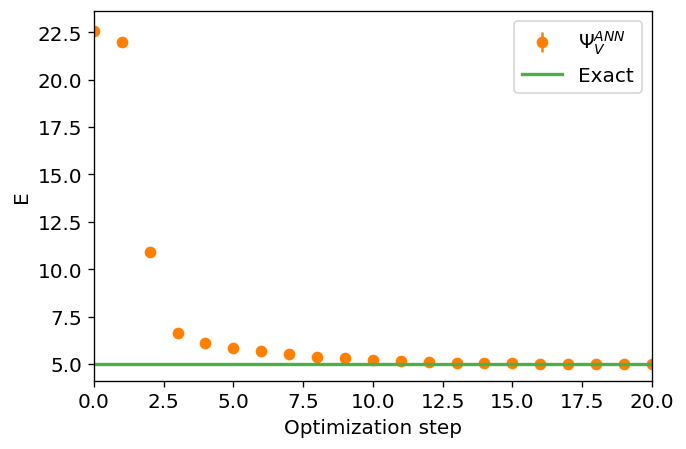

In [16]:
from matplotlib.pyplot import figure
palette = plt.get_cmap('Set1')
figure(num=None, figsize=(6, 4), dpi=120, facecolor='w', edgecolor='k')
plt.rcParams.update({'font.size': 12})

E_exact = ground_state_energy_closed_shell(npart, ndim)

step = jnp.asarray(steps_history)
energy = jnp.real(jnp.asarray(energy_history))
error = jnp.real(jnp.asarray(error_history))

p1 = plt.errorbar(step, energy, yerr=error, fmt='o', errorevery=1, markevery = 1, label = r'$\Psi_{V}^{ANN}$', zorder = 0, color = palette(4))
p2 = plt.axhline(y= E_exact, linestyle = '-', label = 'Exact', color = palette(2), lw = 2)

#plt.ylim(0.46,1)
plt.xlim(0,20)

plt.xlabel(r'Optimization step')
plt.ylabel('E')
plt.legend([p1, p2], [r'$\Psi_{V}^{ANN}$', r'Exact'], loc = 'upper right')
plt.savefig("ho_energies.pdf",bbox_inches = 'tight')
plt.show()

E0= 2.0
